In [1]:
%reset -f

import networkx as nx
import asymmetree.treeevolve as te
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random

from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import orthology_from_tree, bmg_from_tree
from tralda.datastructures.tree import TreeNode
from insertHybrid import insertHybrid
from networkx.drawing.nx_pydot import graphviz_layout
from insertHybrid import convert_to_nx
from insertHybrid import color_leaves

In [2]:
# Zufälligen Genbaum von Assymetree erstellen lassen.
# generate Species Tree

S = te.species_tree_n(n = 2)

# generate Gene Tree

dated_gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=0.5,
    loss_rate=0.1,
    hgt_rate=0,
    dupl_polytomy=0.5
)

full_gene_tree = te.rate_heterogeneity(
    dated_gene_tree,
    S,
    base_rate=0.5,
    autocorr_variance=0.2,
)

# prune all loss branches and the planted root
pruned_gene_tree = te.prune_losses(full_gene_tree)

species_colors, gene_colors = assign_colors(S, dated_gene_tree)

# print(gene_colors)

# visualize(S, color_dict=species_colors)

# visualize(dated_gene_tree, color_dict=gene_colors)
# visualize(full_gene_tree, color_dict=gene_colors)
# visualize(pruned_gene_tree, color_dict=gene_colors)

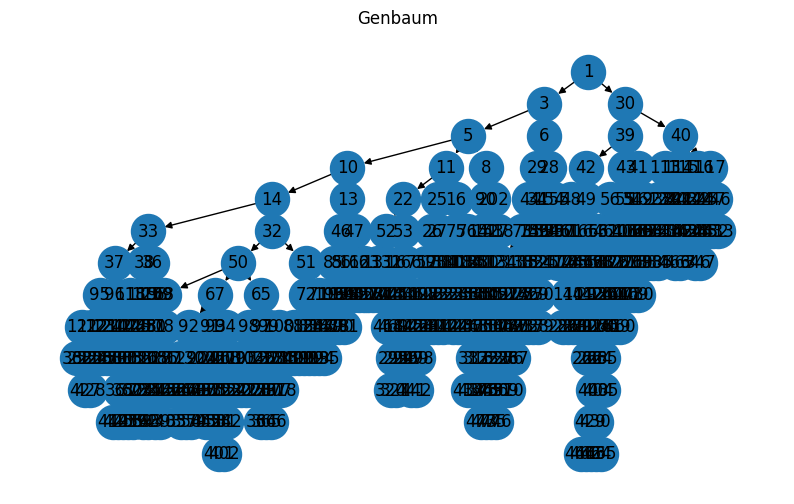

[(1, {'label': 1, 'event': 'D', 'reconc': (0, 1), 'tstamp': 5.772676498472342, 'transferred': 0, 'dist': 0.0}), (3, {'label': 3, 'event': 'D', 'reconc': (0, 1), 'tstamp': 4.938639712821226, 'transferred': 0, 'dist': np.float64(0.42433274109286984), 'sibling_nr': 0}), (5, {'label': 5, 'event': 'D', 'reconc': (0, 1), 'tstamp': 4.85656349172709, 'transferred': 0, 'dist': np.float64(0.17698634467122368), 'sibling_nr': 0}), (10, {'label': 10, 'event': 'D', 'reconc': (0, 1), 'tstamp': 4.556964818932603, 'transferred': 0, 'dist': np.float64(0.1229494938113806), 'sibling_nr': 0}), (14, {'label': 14, 'event': 'D', 'reconc': (0, 1), 'tstamp': 3.6344415650834128, 'transferred': 0, 'dist': np.float64(0.429644202540768), 'sibling_nr': 0}), (33, {'label': 33, 'event': 'D', 'reconc': (0, 1), 'tstamp': 3.0542610843967823, 'transferred': 0, 'dist': np.float64(0.23802869088032783), 'sibling_nr': 0}), (37, {'label': 37, 'event': 'D', 'reconc': (0, 1), 'tstamp': 1.2988899927333915, 'transferred': 0, 'dist

In [3]:
N = convert_to_nx(pruned_gene_tree)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = graphviz_layout(N, prog="dot")

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

print(N.nodes(data = True))

In [5]:
N = insertHybrid(N)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = graphviz_layout(N, prog="dot")

node_colors = color_leaves(N)
# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_color=node_colors,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

# for node in G.nodes(data=True):
#     print(node)

NameError: name 'randomNode' is not defined